# 3. Activation Functions
---
Activation functions are what give neural networks their **power to learn non-linear patterns**. Without them, a deep network is just a linear model in disguise.


## 3.1 Why Activation Functions?

If every layer just computes $z = Wx + b$, stacking layers gives:

$$\text{Layer 2}(\text{Layer 1}(x)) = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$

This is **still just a linear function** — no matter how many layers you add!

<img src="./Images/linear_activate.webp" width="800" height="800" />

Activation functions break this by applying a **non-linear transformation** after each layer.

Activation functions are critical in neural networks because they introduce non-linearity, enabling the model to learn complex, high-dimensional patterns in data. Without them, a network—regardless of depth—would only act as a linear regression model, limiting its predictive power to simple linear transformations.

<img src="./Images/non_linear.webp" width="800" height="800" />

Real-world data (images, text, audio) is rarely linear. **Activation functions** allow neurons to learn these non-linear relationships. Activation functions are differentiable, allowing for backpropagation and the training of deep neural networks to update weights. They also introduce Sparsity, for-example: ReLU (Rectified Linear Unit) sets negative values to 0, meaning some neurons do not activate, creating sparse, more efficient networks

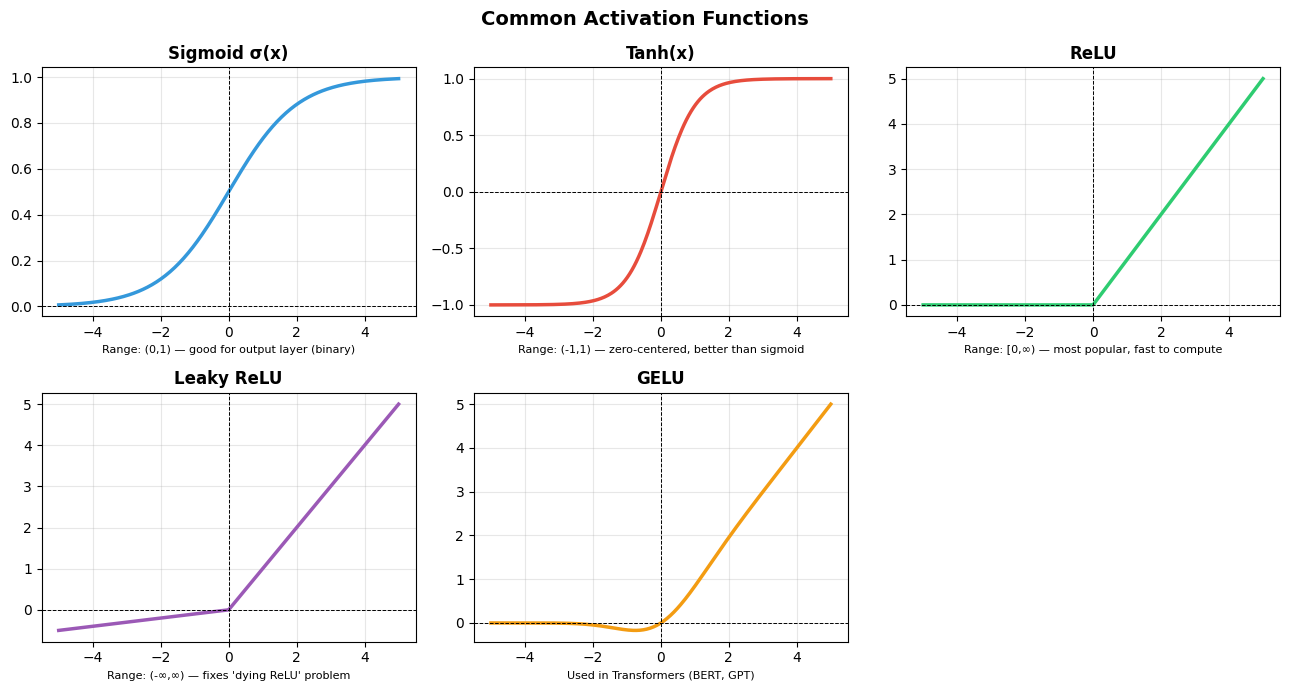

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)

# All activation functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x):    return np.tanh(x)
def relu(x):    return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def gelu(x):    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fns = [
    (sigmoid,    "Sigmoid σ(x)",       "#3498DB", "Range: (0,1) — good for output layer (binary)"),
    (tanh,       "Tanh(x)",            "#E74C3C", "Range: (-1,1) — zero-centered, better than sigmoid"),
    (relu,       "ReLU",               "#2ECC71", "Range: [0,∞) — most popular, fast to compute"),
    (leaky_relu, "Leaky ReLU",         "#9B59B6", "Range: (-∞,∞) — fixes 'dying ReLU' problem"),
    (gelu,       "GELU",               "#F39C12", "Used in Transformers (BERT, GPT)"),
]

for ax, (fn, name, col, note) in zip(axes.flat, fns):
    ax.plot(x, fn(x), color=col, lw=2.5)
    ax.axhline(0, color='k', lw=0.7, linestyle='--')
    ax.axvline(0, color='k', lw=0.7, linestyle='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(note, fontsize=8)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')  # empty slot
plt.suptitle("Common Activation Functions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2 Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

✅ Output between 0 and 1 → good for **binary classification output layer**  
❌ Saturates for large |x| → **vanishing gradient** problem  
❌ Not zero-centered  

**Use:** Output layer for binary classification only.


## 3.3 Tanh

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

✅ Zero-centered (outputs between -1 and 1) — better than sigmoid for hidden layers  
❌ Still saturates → vanishing gradients for large |x|  

**Use:** RNNs (hidden states), some older architectures.


## 3.4 ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x)$$

✅ No saturation for positive values → **no vanishing gradient** on positive side  
✅ Extremely fast to compute  
✅ Sparse activations (many zeros = efficient)  
❌ **Dying ReLU:** neurons that always get negative input → always output 0 → never learn  

**Use:** Default choice for hidden layers in most networks.


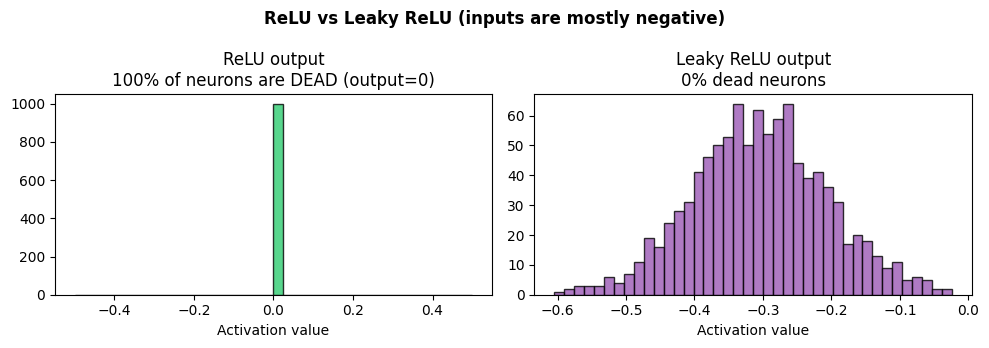

In [2]:
# Demonstrating the Dying ReLU problem
np.random.seed(0)

z = np.random.randn(1000) - 3   # inputs shifted very negative

relu_out = np.maximum(0, z)
leaky_out = np.where(z > 0, z, 0.1 * z)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(relu_out, bins=40, color='#2ECC71', edgecolor='k', alpha=0.8)
axes[0].set_title(f"ReLU output\n{(relu_out == 0).mean()*100:.0f}% of neurons are DEAD (output=0)")
axes[0].set_xlabel("Activation value")

axes[1].hist(leaky_out, bins=40, color='#9B59B6', edgecolor='k', alpha=0.8)
axes[1].set_title(f"Leaky ReLU output\n{(leaky_out == 0).mean()*100:.0f}% dead neurons")
axes[1].set_xlabel("Activation value")

plt.suptitle("ReLU vs Leaky ReLU (inputs are mostly negative)", fontweight='bold')
plt.tight_layout()
plt.show()


## 3.6 Quick Reference

| Activation | Range | Best for | Avoid when |
|---|---|---|---|
| Sigmoid | (0,1) | Binary output | Hidden layers |
| Tanh | (-1,1) | RNN hidden states | Very deep nets |
| ReLU | [0,∞) | Hidden layers (default) | Mostly-negative inputs |
| Leaky ReLU | (-∞,∞) | When ReLU dies | — |
| GELU | (-∞,∞) | Transformers | — |
| Softmax | (0,1) sum=1 | Multi-class output | Hidden layers |


## ✏️ Exercises

A network uses sigmoid activations throughout, and training loss stops decreasing after a few epochs on a deep network. What might be happening and what would you change?
